# Nearest Centroid Classifier


The **Nearest Centroid Classifier** is

- Simple to implement
- Fast and memory efficient
- Interpretable

## Prototypes: Psychological Models of Abstract Ideas

- Neurons receive non-linearly filtered sensory input $\mathbf{x}$
- How can abstract concepts be learned from this information?

## Prototypes: Psychological Models of Abstract Ideas

| | |
|:---:|:---|
| ![Prototypes example data](../figures/prototypes_0.pdf) | How do humans categorize? <br><br> Psychologists postulated that we learn **prototypes** ([Posner 1968](#references); [Jaekel thesis](#references)) <br><br> **Toy data example:** <br> Two dimensional input $$\mathbf{x} \in \mathbb{R}^2$$ <br> Two *classes* of data, $$\Delta$$ and $$\circ$$ |

## Prototypes: Psychological Models of Abstract Ideas

| | |
|:---:|:---|
| ![Prototypes with class means](../figures/prototypes_1.png) | How to compute prototypes? <br><br> Simplest solution: the class means $\boldsymbol{\mu}_\Delta$ and $\boldsymbol{\mu}_o$: $$\boldsymbol{\mu}_\Delta = \frac{1}{N_\Delta} \sum_n^{N_\Delta} \mathbf{x}_{\Delta,n}$$ $$\boldsymbol{\mu}_o = \frac{1}{N_o} \sum_n^{N_o} \mathbf{x}_{o,n}$$ <br> Distance from $\boldsymbol{\mu}_\Delta$ to new data point $\mathbf{x}$: $$\|\boldsymbol{\mu}_\Delta - \mathbf{x}\|_2$$ |

## Prototypes: Psychological Models of Abstract Ideas

| | |
|:---:|:---|
| ![Prototypes with class means](../figures/prototypes_1.png) | For new data $\mathbf{x}$ check: <br><br> **Is $\mathbf{x}$ more similar to $\boldsymbol{\mu}_o$?** $$\|\boldsymbol{\mu}_\Delta - \mathbf{x}\| > \|\boldsymbol{\mu}_o - \mathbf{x}\|$$ <br><br> yes? $\rightarrow$ $\mathbf{x}$ belongs to $\boldsymbol{\mu}_o$ <br> no? $\rightarrow$ $\mathbf{x}$ belongs to $\boldsymbol{\mu}_\Delta$ <br><br> This is called a **nearest centroid classifier** |

## Nearest Centroid Classification: Training

> * Input:
>   * Training Data $x_1,...,x_N \in R^D$
>   * labels $y_1,...,y_N \in {1,...,K}$
> * Output:
>   * Class means $\mu_k,~ k ~\in~ {1,...,K}$


## Nearest Centroid Classification: Prediction

> * Input:
>   * Test Data $x_1,...,x_N \in R^D$
> * Output: 
>   * for each $x$ return label corresponding to closest centroid




## Nearest Centroid Classifier

In [2]:
class NCC:
        
    def fit(self, X, Y):
        # classes
        self.classes = np.unique(Y)
        # compute class means
        self.mu = np.zeros((len(self.classes), X.shape[1]))
        for class_idx, class_label in enumerate(self.classes):
            self.mu[class_idx,:] = X[Y==class_label,:].mean(axis=0)
    
    def predict(self, X):
        # compute distance to all centroids
        dist_to_centroids = np.zeros((X.shape[0], self.mu.shape[0]))
        for class_idx in range(self.mu.shape[0]):
            dist_to_centroids[:,class_idx] = np.sum((X - self.mu[class_idx,:]) ** 2, axis=1)
        return self.classes[dist_to_centroids.argsort(axis=1)[:,0]]

In [7]:
import matplotlib.pylab as pl
import numpy as np
from numpy.random import multivariate_normal as mvn
%matplotlib inline
# %config InlineBackend.figure_format = 'svg'
import matplotlib
matplotlib.use('Agg')
pl.style.use('ggplot')
pl.rcParams['figure.figsize'] = (5.0, 5.0)

def make_data_threeclass(N=90):
    mu = np.array([[0,3],[0,-3],[2,1]]).T
    C = np.array([[5.,4.],[4.,5.]])
    n_samples_per_class = int(N/3)
    X = np.hstack((
        mvn(mu[:,0],C,n_samples_per_class).T,
        mvn(mu[:,1],C,n_samples_per_class).T,
        mvn(mu[:,2],C,n_samples_per_class).T))
    labels = np.ones(n_samples_per_class, dtype=int)
    y = np.hstack((labels,2*labels,3*labels))-1
    # generates some toy data
    return X.T,y.T

def make_data_twoclass(N=100):
    # generates some toy data
    mu = np.array([[0,3],[0,-3]]).T
    n_samples_per_class = int(N/2)
    C = np.array([[5.,4.],[4.,5.]])
    X = np.hstack((
            mvn(mu[:,0],C,n_samples_per_class).T, 
            mvn(mu[:,1],C,n_samples_per_class).T
        ))
    y = np.hstack((np.zeros((n_samples_per_class)),(np.ones((n_samples_per_class)))))
    return X.T,y.T
    

def make_data_spherical(N=100):
    # generates some toy data
    mu = np.array([[0,3],[0,-3]]).T
    n_samples_per_class = int(N/2)
    C = np.eye(2)
    X = np.hstack((
        mvn(mu[:,0],C,n_samples_per_class).T, 
        mvn(mu[:,1],C,n_samples_per_class).T
    ))
    y = np.hstack((np.zeros((n_samples_per_class)),(np.ones((n_samples_per_class)))))
    return X.T,y.T


def make_plot_nclass(X,y,model=None,title_str=''):
    colors = "brymcwg"
    
    if model is not None:
        # Plot the decision boundary.
        h = .02 # stepsize in mesh
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        cs = pl.contourf(xx, yy, Z, cmap=pl.cm.Pastel1_r, alpha=.6)

    # plot the data
    for class_idx, class_name in enumerate(np.unique(y)):
        idx = y == class_name
        pl.plot(X[idx, 0], X[idx, 1], colors[int(class_idx)%6]+'.')
        if model:
            pl.plot(model.mu[class_idx, 0],model.mu[class_idx, 1],colors[int(class_idx)%6]+'.',markersize=20)
    
    pl.axis('tight')
    pl.xlabel('$X_1$')
    pl.ylabel('$X_2$')
    if title_str:
        pl.title(title_str)

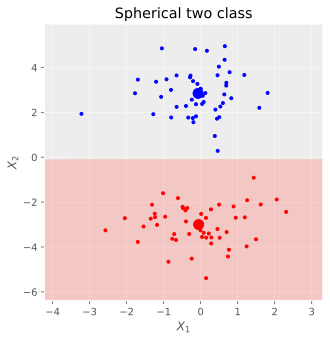

In [3]:
X, Y = make_data_spherical()
ncc = NCC()
mu = ncc.fit(X,Y)
make_plot_nclass(X, Y, model=ncc, title_str='Spherical two class')

### Accuracy of NCC

We can compute how well NCC works by computing the fraction of correct predictions
$$\frac{\text{Correct Predictions}}{\text{All Predictions}}$$

In [4]:
Ypred = ncc.predict(X)
accuracy = (Y==Ypred).mean()
print(f'accuracy {accuracy}')

accuracy 1.0


## When Should I Use NCC?

NCC has assumptions about the data
> Only the averages of each class matter
  
* Does this always hold true for real data?
* What happens when data violates that assumption?
* How does data look like that violates that assumption?
  

### Uncorrelated Data

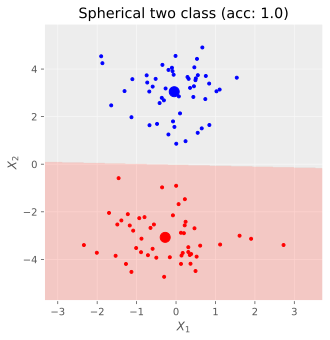

In [5]:
X, Y = make_data_spherical()
ncc = NCC()
ncc.fit(X,Y)
Ypred = ncc.predict(X)
accuracy = (Y==Ypred).mean()
make_plot_nclass(X, Y, model=ncc, title_str=f'Spherical two class (acc: {accuracy})')

### Correlated Data

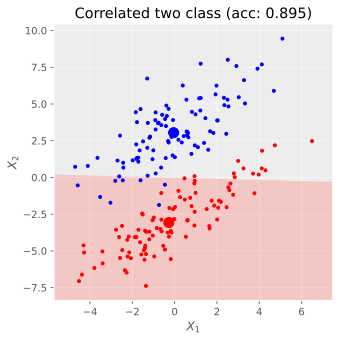

In [6]:
X_correlated, Y_correlated = make_data_twoclass(200)
Ypred_corr = ncc.predict(X_correlated)
accuracy = (Y_correlated==Ypred_corr).mean()
make_plot_nclass(X_correlated, Y_correlated, 
                 model=ncc, 
                 title_str=f'Correlated two class (acc: {accuracy})')

## Nearest Centroid Classification and Linear Classification

- NCC works well for uncorrelated data
> What are examples of correlated data?
- Decision boundary of NCC is a line in feature space
> $\rightarrow$ NCC is a *Linear Classifier*
- We now show that mathematically
> $\rightarrow$ Question: What is the line that separates the classes?

## From Prototypes to Linear Classification

Data point $\mathbf{x}$ is assigned to class $\circ$ if its distance to $\boldsymbol{\mu}_\circ$ is smaller than to $\boldsymbol{\mu}_\Delta$:

$$
\text{distance}(\mathbf{x}, \boldsymbol{\mu}_\Delta) > \text{distance}(\mathbf{x}, \boldsymbol{\mu}_o)
$$

$$
\|\mathbf{x} - \boldsymbol{\mu}_\Delta\|_2 > \|\mathbf{x} - \boldsymbol{\mu}_o\|_2
$$

$$
\Leftrightarrow \|\mathbf{x} - \boldsymbol{\mu}_\Delta\|_2^2 > \|\mathbf{x} - \boldsymbol{\mu}_o\|_2^2
$$

$$
\Leftrightarrow \mathbf{x}^\top\mathbf{x} - 2\boldsymbol{\mu}_\Delta^\top\mathbf{x} + \boldsymbol{\mu}_\Delta^\top\boldsymbol{\mu}_\Delta > \mathbf{x}^\top\mathbf{x} - 2\boldsymbol{\mu}_o^\top\mathbf{x} + \boldsymbol{\mu}_o^\top\boldsymbol{\mu}_o
$$

$$
\Leftrightarrow 0 < \underbrace{(\boldsymbol{\mu}_o - \boldsymbol{\mu}_\Delta)}_{\mathbf{w}}^\top \mathbf{x} - \tfrac{1}{2}\underbrace{(\boldsymbol{\mu}_o^\top\boldsymbol{\mu}_o - \boldsymbol{\mu}_\Delta^\top\boldsymbol{\mu}_\Delta)}_{\beta}
$$

> **Linear Classification**
>
> $$\mathbf{w}^\top\mathbf{x} - \beta = \begin{cases} >0 & \text{if } \mathbf{x} \text{ belongs to class } \circ \\ <0 & \text{if } \mathbf{x} \text{ belongs to class } \Delta \end{cases}$$

## Linear Classification

- A linear classifier predicts class for data point $\mathbf{x}$ as
$$
f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} - \beta
$$
- $\mathbf{w}$ defines the *decision boundary*
- $\beta$ defines the *decision threshold*
- For NCC, $\mathbf{w}$ is the difference of the class means:
$$
\mathbf{w}_{\text{NCC}} = \boldsymbol{\mu}_o - \boldsymbol{\mu}_\Delta
$$

## Linear Classification — Decision Boundary

| | |
|:---:|:---|
| ![Hyperplane decision boundary](../figures/hyperplane.pdf) | $$\mathbf{w}^\top\mathbf{x} - \beta = \begin{cases} >0 & \text{if } \mathbf{x} \text{ belongs to } \circ \\ <0 & \text{if } \mathbf{x} \text{ belongs to } \Delta \end{cases}$$ <br><br> The *threshold* $$\beta$$ can be included in $$\mathbf{w}$$ by augmenting the vectors: $$\tilde{\mathbf{x}} \leftarrow \begin{bmatrix} 1 \\ \mathbf{x} \end{bmatrix} \qquad \tilde{\mathbf{w}} \leftarrow \begin{bmatrix} -\beta \\ \mathbf{w} \end{bmatrix}$$ such that $$\tilde{\mathbf{w}}^\top \tilde{\mathbf{x}} = \mathbf{w}^\top\mathbf{x} - \beta$$ |

## Linear Classification — What is a Good $\mathbf{w}$?

| | |
|:---:|:---|
| ![Hyperplane decision boundary](../figures/hyperplane.pdf) | What is a good $\mathbf{w}$? <br><br> Some proposals: <br> - Logistic Regression <br> - Perceptrons <br> - Support Vector Machines <br> - Ridge Regression <br><br> Linear methods have different ways of defining what a good $\mathbf{w}$ is |

## Linear Classification — NCC as Linear Classifier

| | |
|:---:|:---|
| ![Hyperplane decision boundary](../figures/hyperplane.pdf) | Nearest Centroid Classification is a simple linear classifier: $$\mathbf{w} = \boldsymbol{\mu}_o - \boldsymbol{\mu}_\Delta$$ $$\beta = -\tfrac{1}{2}(\boldsymbol{\mu}_o^\top\boldsymbol{\mu}_o - \boldsymbol{\mu}_\Delta^\top\boldsymbol{\mu}_\Delta)$$ |

## Problems with Linear Classification

Linear Classifiers fail on non-linear problems:

| | |
|:---:|:---:|
| ![Nonlinear problem 1](../figures/perceptron_problem_1.pdf) | ![Nonlinear problem 2](../figures/perceptron_problem_2.pdf) |

Try to separate these two-class data sets with **a single line**.

## Problems with Linear Classification — Non-linear Features

If we can model the non-linearity, we can create new features $\tilde{\mathbf{x}}$ which are linearly separable:

| | |
|:---:|:---:|
| ![Non-linear features 1](../figures/non-linear-features-1.png) | ![Non-linear features 2](../figures/non-linear-features-2.pdf) |

But what if we do not know the non-linearity?

## Summary

- **Psychologists postulated we learn Prototypes**
  - Prototypes can be the class means
  - Prototype theory is closely related to linear classification

- **Nearest Centroid Classification**
  - New data is assigned to class with closest centroid
  - Memory efficient: only requires to store $D$-dimensional centroids
  - Nearest Centroid Classifiers assume uncorrelated features

- **Linear Classification**
  - Nearest Centroid Classifiers are Linear Classifiers
  - Linear Classifiers fail on nonlinear classification problems

## References

<a name="references"></a>

- [Jaekel thesis] Jaekel, F. Dissertation on prototype-based categorization.
- [Posner 1968] Posner, M. I. & Keele, S. W. (1968). On the genesis of abstract ideas. *Journal of Experimental Psychology*, 77(3), 353–363.
- [Rosenblatt 1958] Rosenblatt, F. (1958). The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain. *Psychological Review*, 65(6), 386–408.